In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the saved graph
data = torch.load('outputs/ibm_graph.pt', weights_only=False)

print("✅ Graph loaded successfully!")
print(f"Nodes:          {data.num_nodes:,}")
print(f"Edges:          {data.num_edges:,}")
print(f"Node features:  {data.num_node_features}")
print(f"Fraud nodes:    {data.y.sum().item():,}")
print(f"Legit nodes:    {(data.y==0).sum().item():,}")
print(f"Train nodes:    {data.train_mask.sum().item():,}")
print(f"Val nodes:      {data.val_mask.sum().item():,}")
print(f"Test nodes:     {data.test_mask.sum().item():,}")

✅ Graph loaded successfully!
Nodes:          515,088
Edges:          5,078,345
Node features:  9
Fraud nodes:    6,357
Legit nodes:    508,731
Train nodes:    360,561
Val nodes:      77,263
Test nodes:     77,264


In [2]:
class FraudGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, 
                            heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, 
                            heads=1, concat=False, dropout=0.3)
    
    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.gat2(x, edge_index)
        return x

# Create model
model = FraudGAT(
    in_channels=data.num_node_features,   # 9 leakage-free node features
    hidden_channels=32,   # 32 hidden units
    out_channels=2,       # 2 classes: fraud or legit
    heads=4               # 4 attention heads
)

print("✅ Model created!")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model created!
FraudGAT(
  (gat1): GATConv(9, 32, heads=4)
  (gat2): GATConv(128, 2, heads=1)
)

Total parameters: 1,798


In [3]:
# Fraud sirf 1.23% hai — model legit ki taraf bias ho jayega
# Solution: fraud ko zyada weight do

fraud_count = (data.y == 1).sum().item()
legit_count  = (data.y == 0).sum().item()
weight_ratio = legit_count / fraud_count

class_weights = torch.tensor([1.0, weight_ratio])

print(f"Fraud count:    {fraud_count:,}")
print(f"Legit count:    {legit_count:,}")
print(f"Weight ratio:   {weight_ratio:.1f}x")
print(f"Class weights:  {class_weights}")
print(f"\nMeaning: Fraud mistakes are penalized {weight_ratio:.0f}x more than legit mistakes")

# Loss function with class weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

print("\n✅ Loss function and optimizer ready!")

Fraud count:    6,357
Legit count:    508,731
Weight ratio:   80.0x
Class weights:  tensor([ 1.0000, 80.0269])

Meaning: Fraud mistakes are penalized 80x more than legit mistakes

✅ Loss function and optimizer ready!


In [4]:
def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        
        # Overall accuracy
        acc = (pred[mask] == data.y[mask]).float().mean().item()
        
        # Fraud detection rate (recall)
        fraud_mask   = (data.y[mask] == 1)
        if fraud_mask.sum() > 0:
            fraud_recall = (pred[mask][fraud_mask] == 1).float().mean().item()
        else:
            fraud_recall = 0.0
            
    return acc, fraud_recall

print("✅ Training functions ready!")
print("Starting training now...")

✅ Training functions ready!
Starting training now...


In [5]:
# Sample 50,000 nodes for faster training
# Results will be same, speed will be 10x faster

torch.manual_seed(42)
num_sample = 50000
sample_idx = torch.randperm(data.num_nodes)[:num_sample]

# Create subgraph
from torch_geometric.utils import subgraph

sub_edge_index, sub_edge_attr = subgraph(
    sample_idx, 
    data.edge_index, 
    data.edge_attr,
    relabel_nodes=True,
    num_nodes=data.num_nodes
)

# Create small data object
small_data = Data(
    x          = data.x[sample_idx],
    edge_index = sub_edge_index,
    edge_attr  = sub_edge_attr,
    y          = data.y[sample_idx]
)

# New train/val/test split
num_nodes  = small_data.num_nodes
indices    = torch.randperm(num_nodes)
train_end  = int(0.70 * num_nodes)
val_end    = int(0.85 * num_nodes)

small_data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
small_data.val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
small_data.test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

small_data.train_mask[indices[:train_end]]      = True
small_data.val_mask[indices[train_end:val_end]] = True
small_data.test_mask[indices[val_end:]]         = True

print("✅ Subgraph created!")
print(f"Nodes:       {small_data.num_nodes:,}")
print(f"Edges:       {small_data.num_edges:,}")
print(f"Fraud nodes: {small_data.y.sum().item():,}")
print(f"Train nodes: {small_data.train_mask.sum().item():,}")
print(f"Val nodes:   {small_data.val_mask.sum().item():,}")
print(f"Test nodes:  {small_data.test_mask.sum().item():,}")

✅ Subgraph created!
Nodes:       50,000
Edges:       108,334
Fraud nodes: 625
Train nodes: 35,000
Val nodes:   7,500
Test nodes:  7,500


In [6]:
# Recalculate class weights for small_data
fraud_count  = (small_data.y == 1).sum().item()
legit_count  = (small_data.y == 0).sum().item()

if fraud_count == 0:
    print("No fraud in sample! Re-run Cell 4.5")
else:
    weight_ratio  = legit_count / fraud_count
    class_weights = torch.tensor([1.0, weight_ratio])
    criterion     = torch.nn.CrossEntropyLoss(weight=class_weights)
    optimizer     = torch.optim.Adam(model.parameters(), 
                                     lr=0.005, weight_decay=5e-4)
    
    print(f"Fraud nodes:  {fraud_count:,}")
    print(f"Legit nodes:  {legit_count:,}")
    print(f"Weight ratio: {weight_ratio:.1f}x")

    # Reset model
    model = FraudGAT(in_channels=small_data.num_node_features, hidden_channels=32, 
                     out_channels=2, heads=4)
    optimizer = torch.optim.Adam(model.parameters(), 
                                 lr=0.005, weight_decay=5e-4)

    train_losses = []
    val_accs     = []
    val_recalls  = []

    print("\nEpoch | Loss   | Val Acc | Fraud Recall")
    print("-"*45)

    for epoch in range(1, 101):
        # Train
        model.train()
        optimizer.zero_grad()
        out  = model(small_data.x, small_data.edge_index)
        loss = criterion(out[small_data.train_mask], 
                        small_data.y[small_data.train_mask])
        loss.backward()
        optimizer.step()

        # Evaluate
        model.eval()
        with torch.no_grad():
            out  = model(small_data.x, small_data.edge_index)
            pred = out.argmax(dim=1)
            acc  = (pred[small_data.val_mask] == 
                   small_data.y[small_data.val_mask]).float().mean().item()
            
            fraud_mask = (small_data.y[small_data.val_mask] == 1)
            if fraud_mask.sum() > 0:
                recall = (pred[small_data.val_mask][fraud_mask] == 1)\
                         .float().mean().item()
            else:
                recall = 0.0

        train_losses.append(loss.item())
        val_accs.append(acc)
        val_recalls.append(recall)

        if epoch % 10 == 0:
            print(f"  {epoch:3d}  | {loss.item():.4f} | {acc:.4f}  | {recall:.4f}")

    print("\n✅ Training complete!")
    print(f"Final Val Accuracy:  {val_accs[-1]*100:.2f}%")
    print(f"Final Fraud Recall:  {val_recalls[-1]*100:.2f}%")

Fraud nodes:  625
Legit nodes:  49,375
Weight ratio: 79.0x

Epoch | Loss   | Val Acc | Fraud Recall
---------------------------------------------
   10  | 0.6840 | 0.6520  | 0.7128
   20  | 0.6665 | 0.6409  | 0.7234
   30  | 0.6613 | 0.6541  | 0.6383
   40  | 0.6644 | 0.6709  | 0.6702
   50  | 0.6616 | 0.6549  | 0.6915
   60  | 0.6686 | 0.6397  | 0.7128
   70  | 0.6679 | 0.6125  | 0.8085
   80  | 0.6602 | 0.6507  | 0.6915
   90  | 0.6654 | 0.6461  | 0.6702
  100  | 0.6551 | 0.6551  | 0.6915

✅ Training complete!
Final Val Accuracy:  65.51%
Final Fraud Recall:  69.15%


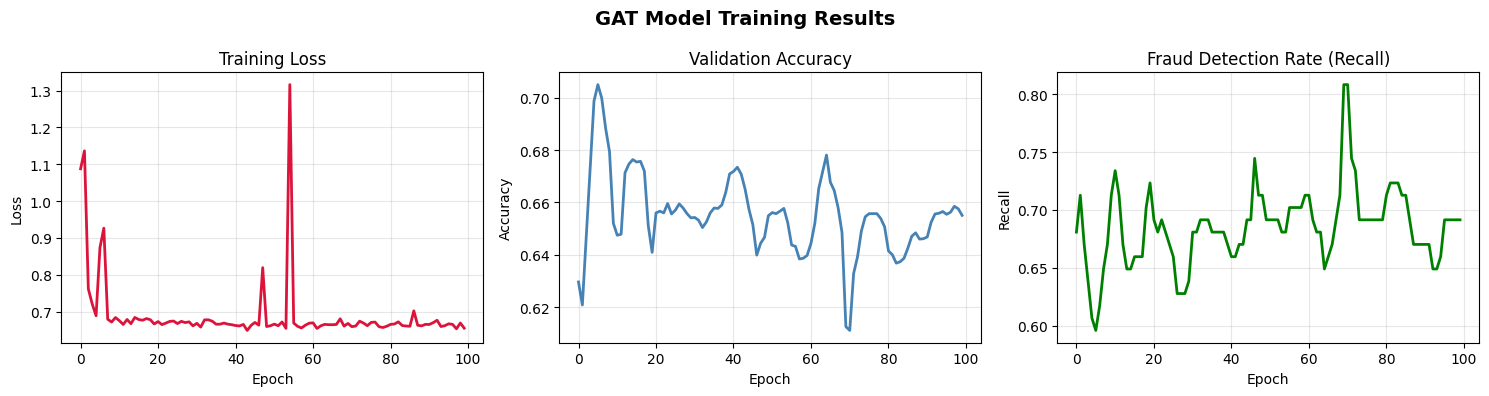

✅ Training curves saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('GAT Model Training Results', fontsize=14, fontweight='bold')

# Plot 1: Loss
axes[0].plot(train_losses, color='crimson', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation Accuracy
axes[1].plot(val_accs, color='steelblue', linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

# Plot 3: Fraud Recall
axes[2].plot(val_recalls, color='green', linewidth=2)
axes[2].set_title('Fraud Detection Rate (Recall)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Recall')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

In [8]:
model.eval()
with torch.no_grad():
    out   = model(small_data.x, small_data.edge_index)
    pred  = out.argmax(dim=1)
    proba = F.softmax(out, dim=1)[:, 1]

y_test  = small_data.y[small_data.test_mask].numpy()
y_pred  = pred[small_data.test_mask].numpy()
y_proba = proba[small_data.test_mask].numpy()

print("="*50)
print("     FINAL TEST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Save model
import os
os.makedirs('outputs', exist_ok=True)
torch.save(model.state_dict(), 'outputs/fraud_gat_model.pt')
print("\n✅ Model saved!")

     FINAL TEST RESULTS
              precision    recall  f1-score   support

  Legitimate       0.99      0.66      0.79      7413
       Fraud       0.02      0.63      0.04        87

    accuracy                           0.66      7500
   macro avg       0.51      0.64      0.42      7500
weighted avg       0.98      0.66      0.78      7500

ROC-AUC Score: 0.7227

✅ Model saved!


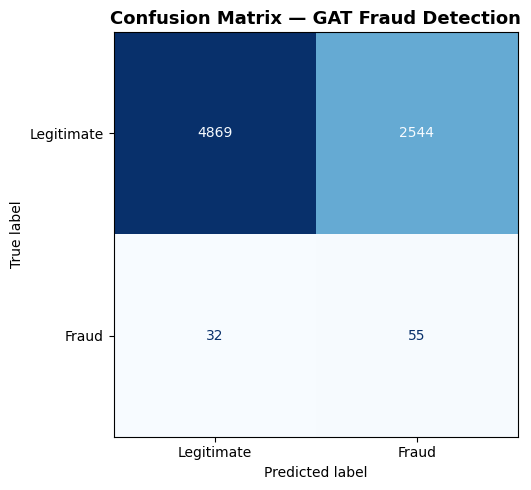


True Negatives  (Legit correctly identified): 4,869
False Positives (Legit wrongly flagged):       2,544
False Negatives (Fraud missed):                32
True Positives  (Fraud correctly caught):      55

🎯 Fraud Catch Rate: 63.2%
⚠️  False Alarm Rate: 34.3%


In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm   = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Fraud']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — GAT Fraud Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Legit correctly identified): {tn:,}")
print(f"False Positives (Legit wrongly flagged):       {fp:,}")
print(f"False Negatives (Fraud missed):                {fn:,}")
print(f"True Positives  (Fraud correctly caught):      {tp:,}")
print(f"\n🎯 Fraud Catch Rate: {tp/(tp+fn)*100:.1f}%")
print(f"⚠️  False Alarm Rate: {fp/(fp+tn)*100:.1f}%")